# 👥 Employee Attrition Prediction: ML for Workforce Analytics

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting employee attrition to support workforce planning and retention strategy  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting employee attrition using satisfaction surveys, compensation data, and career progression features. The model enables **proactive retention interventions** before key talent departs.

### Government Policy Context
- **APSC (Australian Public Service Commission)** — APS Employee Census, Workforce Strategy, State of the Service Report
- **DEWR (Dept of Employment & Workplace Relations)** — Labour market analytics, skills shortage forecasting
- **Finance / ANAO** — Workforce cost efficiency, recruitment ROI, agency capability reviews
- **Defence** — Critical skills retention (cyber, engineering, intelligence), ADF workforce planning
- **Services Australia** — Contact centre attrition (historically 20-30% p.a.), surge workforce planning

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High attrition risk | Retention conversation, career development plan | Direct manager + HR |
| Moderate risk | Monitor engagement, check-in schedule | HR business partner |
| Low risk (confident) | Standard engagement cycle | Automated HR system |
| Low risk (new starter) | Enhanced onboarding, buddy program | Team lead |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv

Loaded: 1,470 rows x 35 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. Age                                 | int64      | unique=   43 | nulls=  0 | eg: 41
   1. Attrition                           | object     | unique=    2 | nulls=  0 | eg: Yes
   2. BusinessTravel                      | object     | unique=    3 | nulls=  0 | eg: Travel_Rarely
   3. DailyRate                           | int64      | unique=  886 | nulls=  0 | eg: 1102
   4. Department                          | object     | unique=    3 | nulls=  0 | eg: Sales
   5. DistanceFromHome                    | int64      | unique=   29 | nulls=  0 | eg: 1
   6. Education                           | int64      | unique=    5 | nulls=  0 | eg: 2
   7. EducationField                      | object     | unique=    6 | nulls=  0 | eg: Life Sciences
   8. EmployeeCount                       | int64      | unique=    1 | nulls=  0 | eg: 1
   9. EmployeeNumber                      | int64      | unique= 1470 | nulls=  0 | eg: 1
  10. EnvironmentSatisfaction             | int64  

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['Attrition', 'attrition', 'left', 'Left', 'turnover', 'Target', 'target', 'Class']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break
if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")
if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values: {df[target_col].unique()}")

if df[target_col].dtype == 'object':
    yes_keywords = ['Yes', 'yes', 'Y', 'TRUE', 'True', '1', 'Left', 'Voluntary']
    mapping = {v: (1 if v in yes_keywords else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'Attrition'

Raw values: ['Yes' 'No']
Mapped: {'Yes': 1, 'No': 0}

Distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Proportions:
Attrition
0    0.8388
1    0.1612
Name: proportion, dtype: float64

Imbalance ratio: 0.192


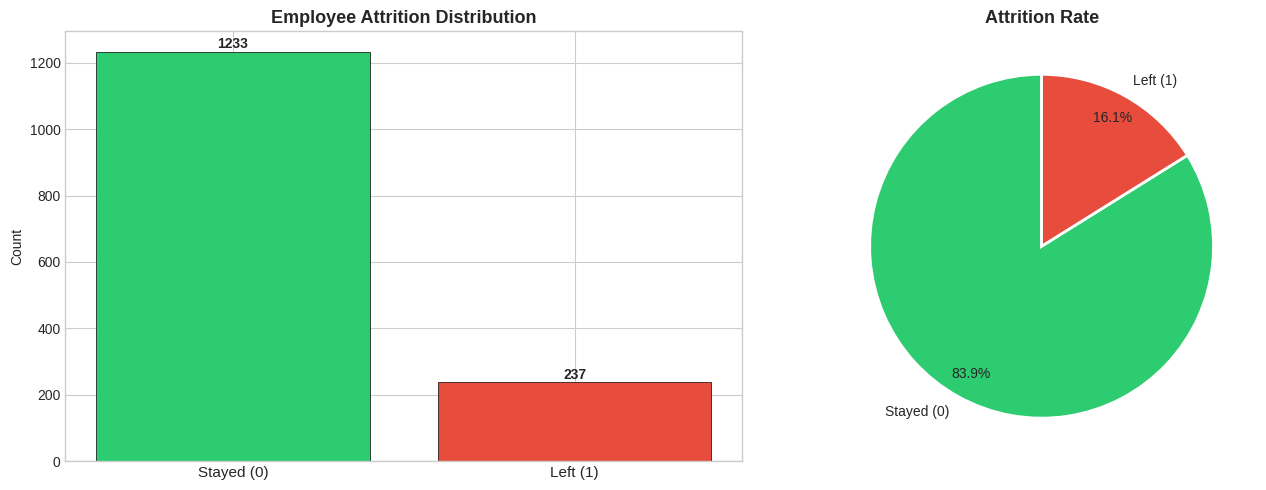

APS context: Average APS separation rate ~7-8% p.a. (APSC State of the Service).
Some agencies (Services Australia, Defence) experience 15-20% in frontline roles.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['Stayed (0)', 'Left (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Employee Attrition Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Rate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("APS context: Average APS separation rate ~7-8% p.a. (APSC State of the Service).")
print("Some agencies (Services Australia, Defence) experience 15-20% in frontline roles.")


## 3. Exploratory Data Analysis

Key questions for workforce policy:
- Which factors most strongly predict attrition?
- Does job satisfaction / work-life balance correlate with leaving?
- Are there compensation thresholds below which attrition spikes?
- Do career progression patterns (years since promotion) matter?


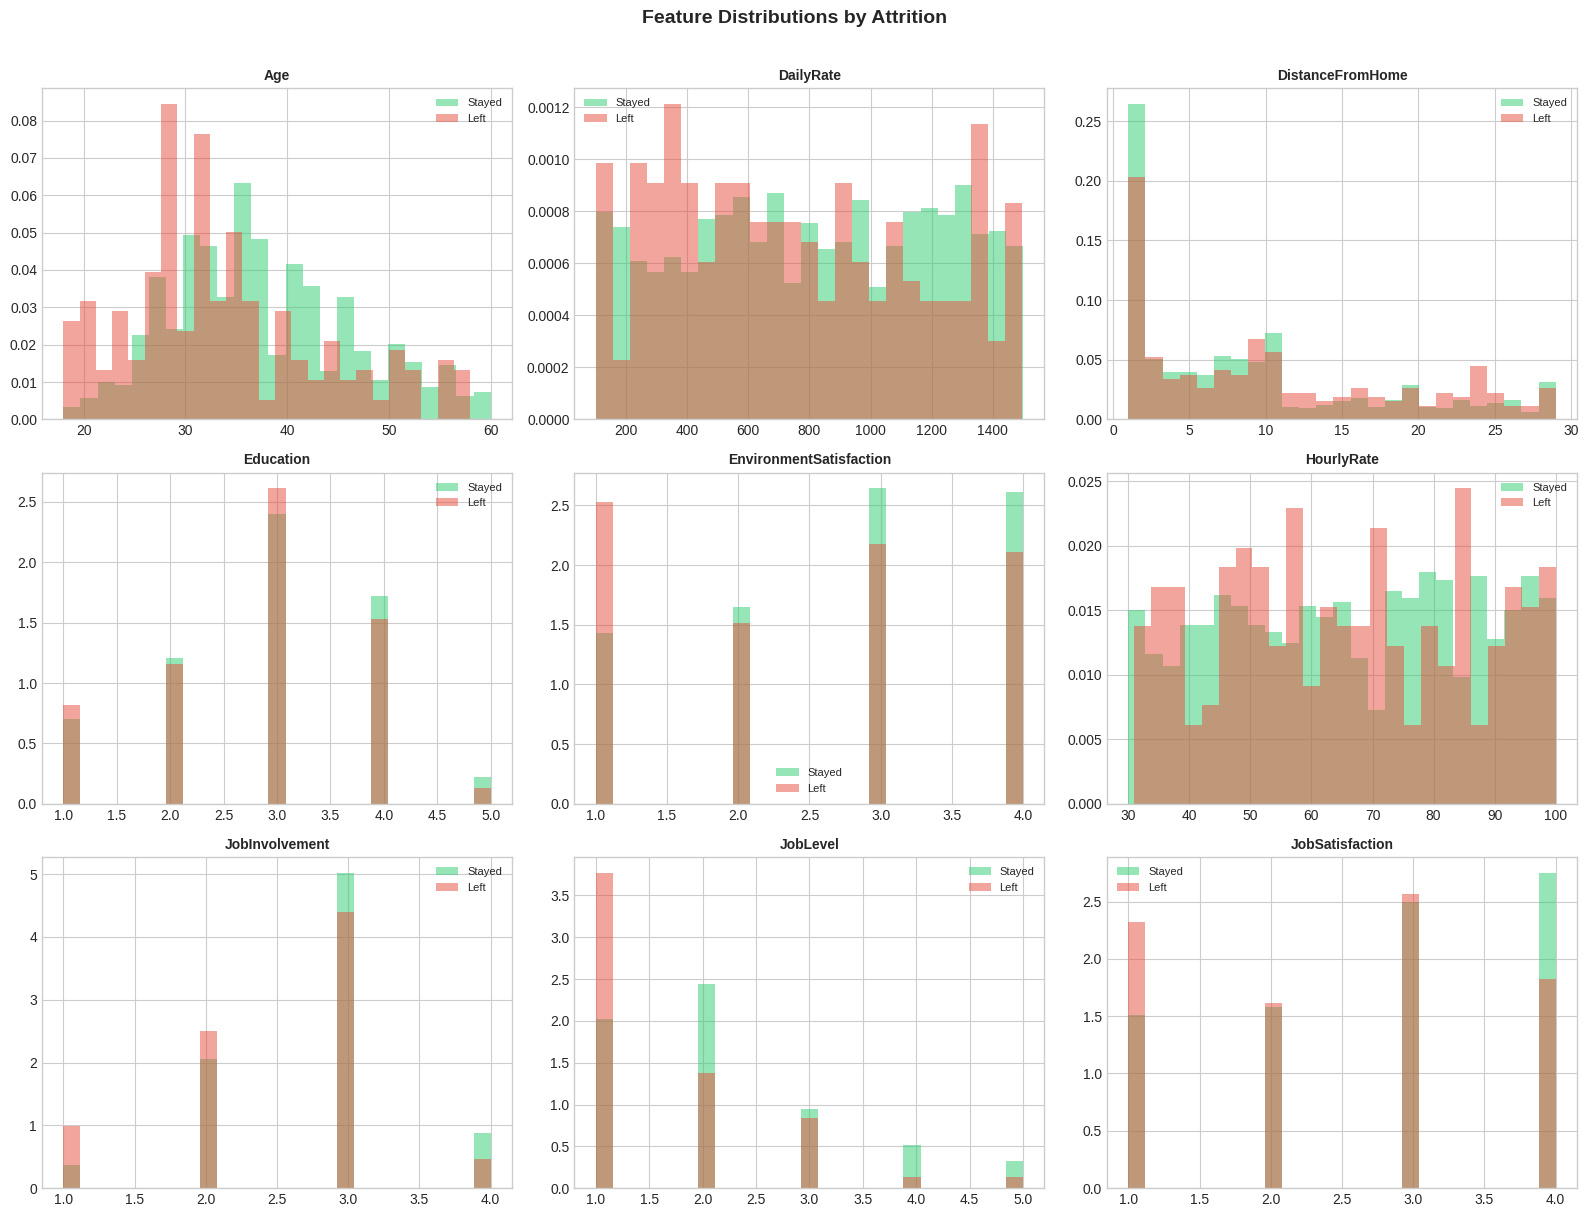

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
# Drop constant/near-constant columns
numeric_cols = [c for c in numeric_cols if df[c].nunique() > 1 and c.lower() not in
                ['employeecount', 'standardhours', 'employeenumber', 'over18']]

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['Stayed', 'Left']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distributions by Attrition', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


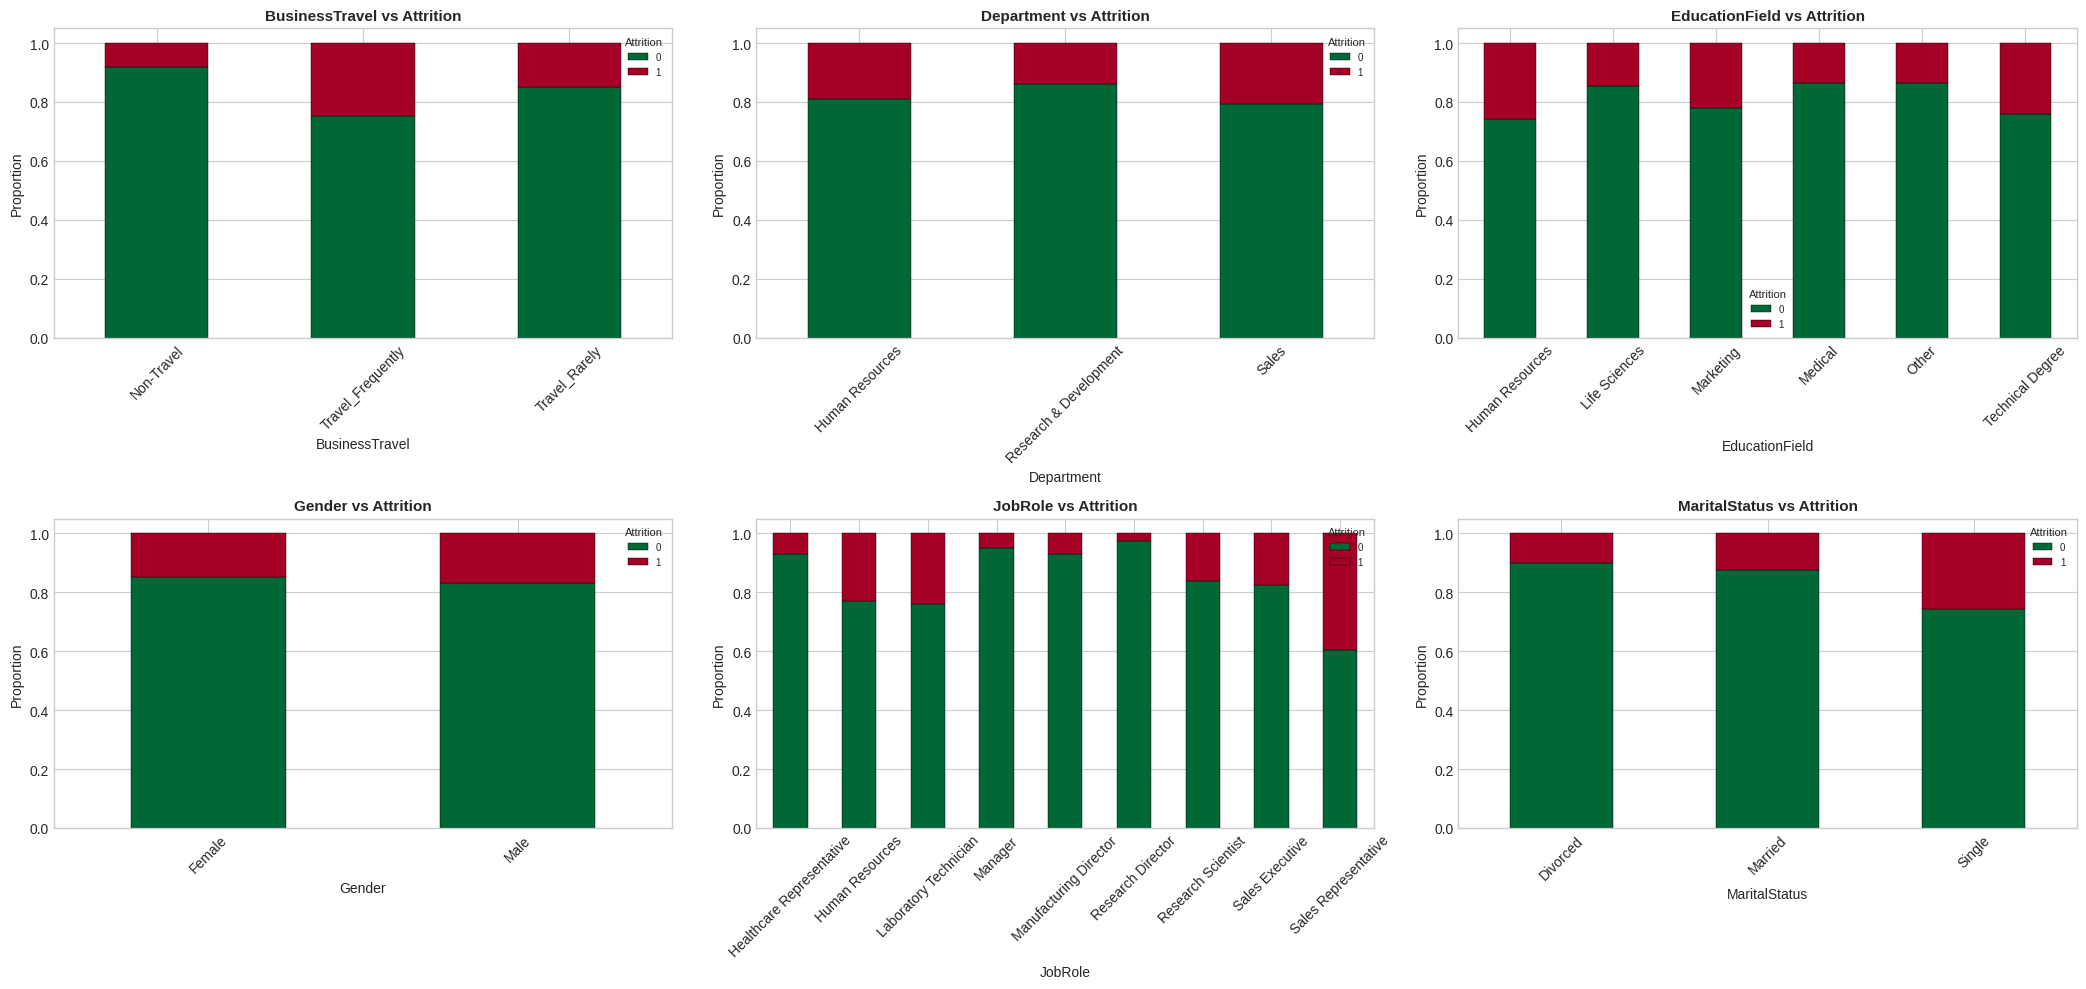

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Attrition', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


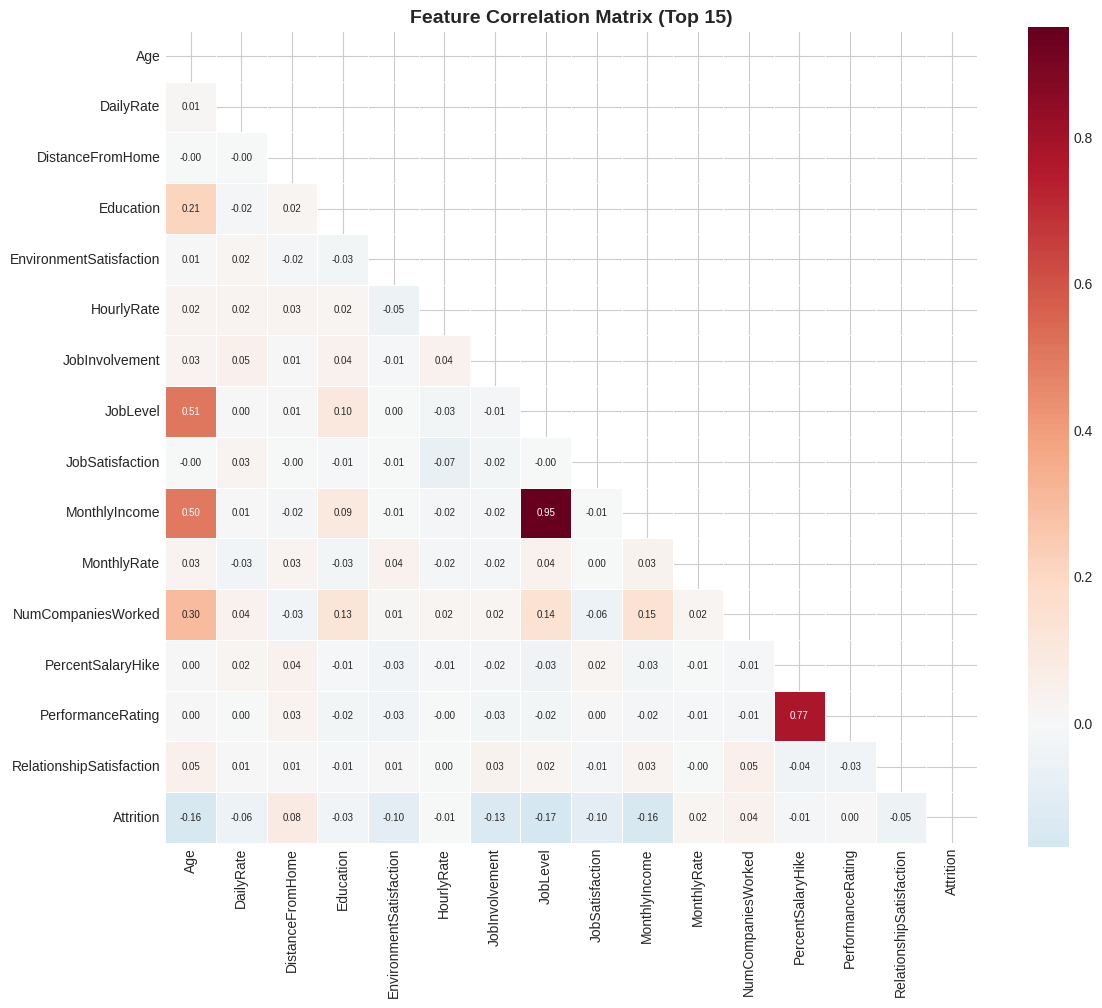

Top correlations with attrition:
  JobLevel                            -0.1691
  MonthlyIncome                       -0.1598
  Age                                 -0.1592
  JobInvolvement                      -0.1300
  JobSatisfaction                     -0.1035
  EnvironmentSatisfaction             -0.1034
  DistanceFromHome                    +0.0779
  DailyRate                           -0.0567
  RelationshipSatisfaction            -0.0459
  NumCompaniesWorked                  +0.0435


In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols[:15] + [target_col]  # limit to 15 for readability
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
                linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Feature Correlation Matrix (Top 15)', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Top correlations with attrition:")
    for feat, val in target_corr.head(10).items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:35s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

HR analytics benefits from engagement composite scores:
- **Satisfaction composite** — combining job, environment, relationship satisfaction
- **Career velocity** — years at company vs total working years
- **Compensation competitiveness** — income relative to role/education peers
- Drop constant columns (EmployeeCount, StandardHours, Over18)


In [9]:
df_model = df.copy()

# Replace '?' with NaN
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)
            print(f"  Replaced {n_q} '?' in '{col}'")

# Drop constant/useless columns
drop_candidates = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
drop_cols = [c for c in drop_candidates if c in df_model.columns]
if drop_cols:
    print(f"Dropping constant/ID columns: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
print(f"\nTarget: {np.unique(y)} counts: {dict(zip(*np.unique(y, return_counts=True)))}")
assert len(np.unique(y)) >= 2

null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values...")
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")


Dropping constant/ID columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
  Encoded 'BusinessTravel': 3 classes
  Encoded 'Department': 3 classes
  Encoded 'EducationField': 6 classes
  Encoded 'Gender': 2 classes
  Encoded 'JobRole': 9 classes
  Encoded 'MaritalStatus': 3 classes
  Encoded 'OverTime': 2 classes

Target: [0 1] counts: {np.int64(0): np.int64(1233), np.int64(1): np.int64(237)}

Feature matrix: (1470, 30)


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Satisfaction composite
sat_cols = [c for c in feature_names if 'satisfaction' in c.lower()]
if len(sat_cols) >= 2:
    X['satisfaction_composite'] = X[sat_cols].mean(axis=1)
    composites_added.append('satisfaction_composite')
    print(f"Created 'satisfaction_composite' from {sat_cols}")

# Career velocity
years_company = [c for c in feature_names if c.lower() == 'yearsatcompany']
total_working = [c for c in feature_names if c.lower() == 'totalworkingyears']
if years_company and total_working:
    X['career_velocity'] = X[years_company[0]] / (X[total_working[0]] + 1)
    composites_added.append('career_velocity')
    print(f"Created 'career_velocity'")

# Stagnation indicator (years since last promotion)
promo_cols = [c for c in feature_names if 'promotion' in c.lower() or 'lastpromotion' in c.lower()
              or c.lower() == 'yearssincelastpromotion']
if promo_cols:
    X['promotion_stagnation'] = (X[promo_cols[0]] > X[promo_cols[0]].median()).astype(int)
    composites_added.append('promotion_stagnation')
    print(f"Created 'promotion_stagnation' from {promo_cols[0]}")

# Income relative to age (compensation competitiveness proxy)
income_cols = [c for c in feature_names if 'monthlyincome' in c.lower() or 'monthly_income' in c.lower()]
age_cols = [c for c in feature_names if c.lower() == 'age']
if income_cols and age_cols:
    X['income_per_age'] = X[income_cols[0]] / (X[age_cols[0]] + 1)
    composites_added.append('income_per_age')
    print(f"Created 'income_per_age'")

# Overtime + distance interaction (burnout risk)
overtime_cols = [c for c in feature_names if 'overtime' in c.lower()]
distance_cols = [c for c in feature_names if 'distance' in c.lower()]
if overtime_cols and distance_cols:
    X['burnout_risk'] = X[overtime_cols[0]] * X[distance_cols[0]]
    composites_added.append('burnout_risk')
    print(f"Created 'burnout_risk'")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'satisfaction_composite' from ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction']
Created 'career_velocity'
Created 'promotion_stagnation' from YearsSinceLastPromotion
Created 'income_per_age'
Created 'burnout_risk'

Total engineered: 5
Final feature count: 35


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Mean Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8429  F1=0.3186  AUC=0.7508
  Fold 2: Acc=0.8714  F1=0.3883  AUC=0.8131
  Fold 3: Acc=0.8551  F1=0.3604  AUC=0.7786
  -- Mean Acc: 0.8565  F1: 0.3558  AUC: 0.7808  Time: 1.54s

Training: Random Forest
  Fold 1: Acc=0.8449  F1=0.2549  AUC=0.7747
  Fold 2: Acc=0.8633  F1=0.2637  AUC=0.8527
  Fold 3: Acc=0.8551  F1=0.2828  AUC=0.7873
  -- Mean Acc: 0.8544  F1: 0.2672  AUC: 0.8049  Time: 1.09s

Training: XGBoost
  Fold 1: Acc=0.8429  F1=0.4122  AUC=0.7778
  Fold 2: Acc=0.8898  F1=0.5091  AUC=0.8392
  Fold 3: Acc=0.8714  F1=0.4522  AUC=0.7770
  -- Mean Acc: 0.8680  F1: 0.4578  AUC: 0.7980  Time: 0.37s

Training: LightGBM
  Fold 1: Acc=0.8510  F1=0.3866  AUC=0.7749
  Fold 2: Acc=0.8755  F1=0.4078  AUC=0.8247
  Fold 3: Acc=0.8694  F1=0.4667  AUC=0.7992
  -- Mean Acc: 0.8653  F1: 0.4203  AUC: 0.7996  Time: 0.44s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
      Random Forest 0.8544 +/- 0.0075 0.2672 +/- 0.0117 0.8049 +/- 0.0342 0.1058 1.09s
           LightGBM 0.8653 +/- 0.0104 0.4203 +/- 0.0339 0.7996 +/- 0.0204 0.1128 0.44s
            XGBoost 0.8680 +/- 0.0193 0.4578 +/- 0.0398 0.7980 +/- 0.0291 0.1129 0.37s
Logistic Regression 0.8565 +/- 0.0117 0.3558 +/- 0.0287 0.7808 +/- 0.0255 0.1096 1.54s

Best model: Random Forest


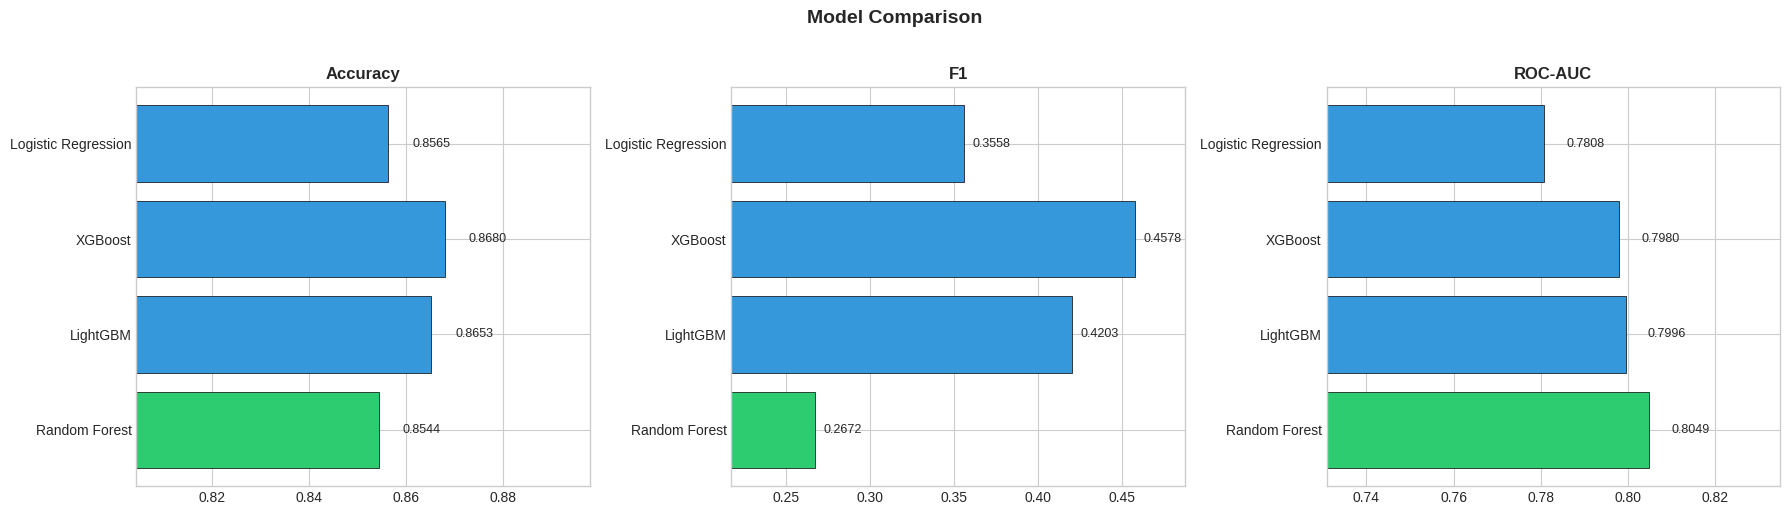

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For workforce retention:
- **False negatives** (missed leavers) = unexpected departures, knowledge loss, recruitment costs ($15-50K per APS employee)
- **False positives** (flagging stayers) = unnecessary retention spend, potential morale impact if interventions feel intrusive


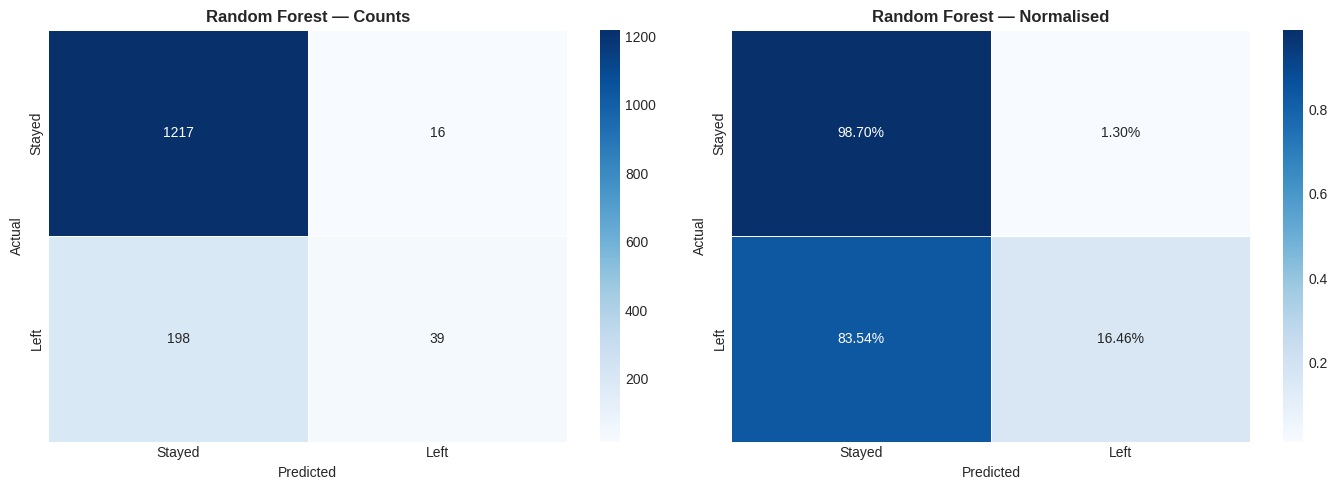


              precision    recall  f1-score   support

      Stayed       0.86      0.99      0.92      1233
        Left       0.71      0.16      0.27       237

    accuracy                           0.85      1470
   macro avg       0.78      0.58      0.59      1470
weighted avg       0.84      0.85      0.81      1470



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Stayed', 'Left']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


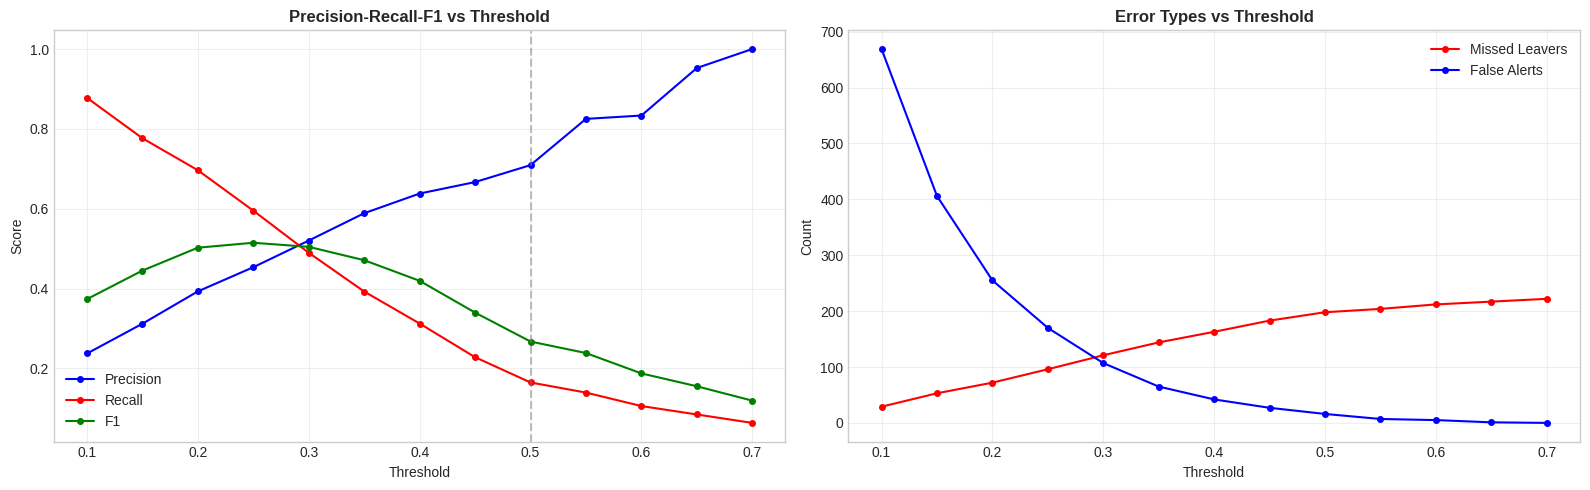


Optimal threshold (F1): 0.25


In [16]:
thresholds = np.arange(0.10, 0.75, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Leavers (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alerts (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', label='Recall', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', label='F1', ms=4)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Leavers (FN)'], 'r-o', label='Missed Leavers', ms=4)
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alerts (FP)'], 'b-o', label='False Alerts', ms=4)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Policy Insights

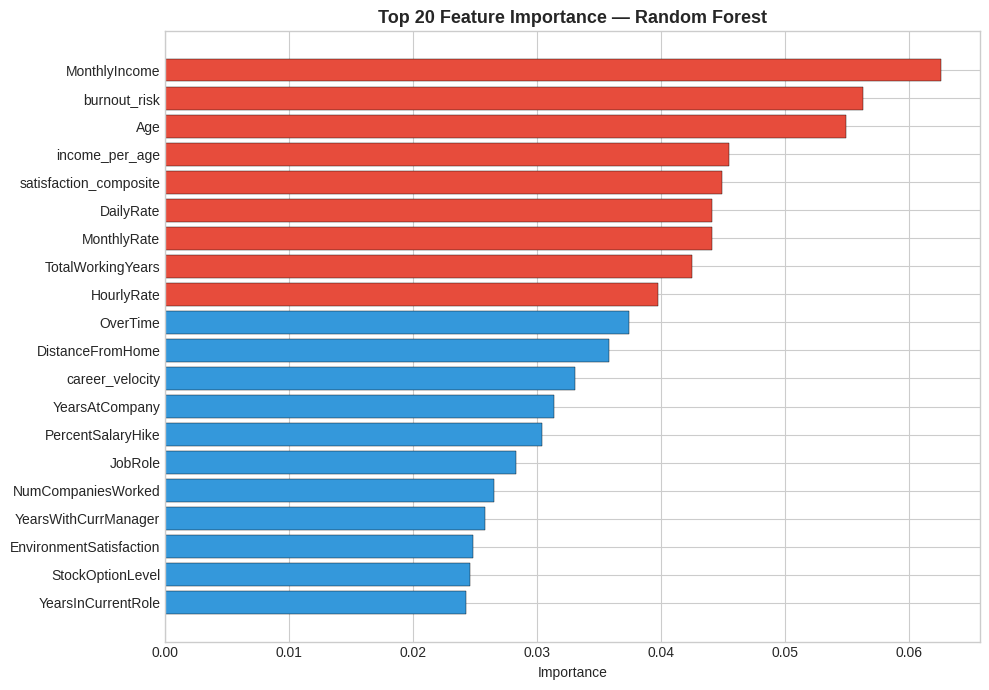

TOP 5 PREDICTIVE FEATURES
  MonthlyIncome                        0.0626
  burnout_risk                         0.0562
  Age                                  0.0549
  income_per_age                       0.0455
  satisfaction_composite               0.0449


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(20)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.35)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 20 Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


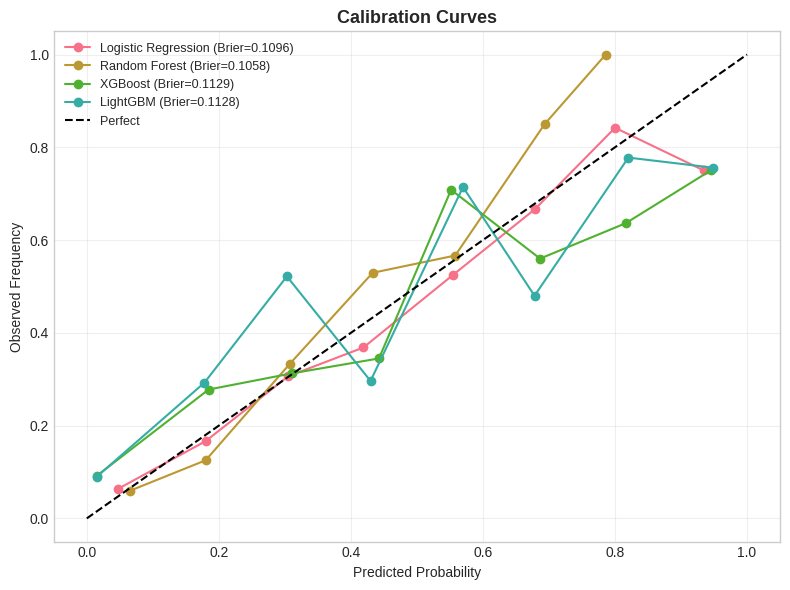

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.70': best_res['auc_mean'] > 0.70,
    'F1 > 0.30': best_res['f1_mean'] > 0.30,
    'Brier < 0.20': best_res['brier_mean'] < 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  ROC-AUC:              0.8049
  F1:                   0.2672
  Precision:            0.7551
  Recall:               0.1646
  Brier Score:          0.1058
  Training time:        1.1s
  Feature count:        35
  Dataset rows:         1,470
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.25

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.70
  [FAIL] F1 > 0.30
  [pass] Brier < 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  SOME CHECKS FAILED


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: HRMIS (SAP SuccessFactors / Aurion), APS Employee Census
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (satisfaction scores, compensation, tenure)
   Schedule: Monthly batch after payroll + quarterly after Census

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring (monthly risk scores per employee)
   Output: Risk tier (High/Medium/Low) + top 3 contributing factors
   Privacy: Model outputs restricted to HR and direct managers only

3. INTEGRATION POINTS
   HR dashboard: Power BI (attrition risk heatmap by branch/team)
   Manager portal: Individual risk scores + recommended actions
   Workforce planning: Aggregate risk by capability/classification level
   Recruitment: Trigger early pipeline building when team risk is high

4. FAIRNESS & GOVERNANCE
   Protected: Age, gender, disability, cultural background, union membership
   Fairness: APS Values and Code of Conduct compliance
   Explainability: SHAP values — no action taken solely on model output
   Privacy: Australian Privacy Principles, APS employee data handling
   Ethics: Model reviewed by agency Ethics Committee
   Human-in-the-loop: All interventions initiated by humans, not automated

5. MONITORING & RETRAINING
   Drift: PSI on feature distributions quarterly
   Performance: AUC on actual separation data (6-month lag)
   Retraining: Annually post-Census with updated satisfaction data
   Bias audit: Annual review across protected attributes
   Benchmarking: Compare model predictions vs APS-wide separation rates

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: HRMIS (SAP SuccessFactors / Aurion), APS Employee Census
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (satisfaction scores, compensation, tenure)
   Schedule: Monthly batch after payroll + quarterly after Census

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring (monthly risk scores per employee)
   Output: Risk tier (High/Medium/Low) + top 3 contributing factors
   Privacy: Model outputs restricted to HR and direct managers only

3. INTEGRATION POINTS
   HR dashboard: Power BI (attrition risk heatmap by branch/team)
   Manager portal: Individual risk scores + recommended actions
   Workforce planning: Aggregate risk by capability/classification level
   Recruitment: Trigger early pipeline building when team risk is high

4. FAIRNESS & GOVERNANCE
   Protected: Age, gender, disability, cultural background, union membership
   Fairness: APS